In [1]:
import os
from typing import TypedDict, Annotated, List, Literal
from langchain_core.messages import BaseMessage, HumanMessage, AIMessage, SystemMessage
from langchain_groq import ChatGroq
from langchain_core.tools import tool
from langchain_community.tools.tavily_search import TavilySearchResults
from langgraph.graph import StateGraph, END
from langgraph.prebuilt import create_react_agent
from langgraph.checkpoint.memory import MemorySaver


C:\Users\anipi\AppData\Local\Temp\ipykernel_23944\377876617.py:6: DeprecationWarning: `langchain-community` is being sunset and is no longer actively maintained. See https://github.com/langchain-ai/langchain-community/issues/674 for details and migration guidance toward standalone integration packages.
  from langchain_community.tools.tavily_search import TavilySearchResults


In [2]:
import os
from dotenv import load_dotenv

load_dotenv()

os.environ["GROQ_API_KEY"] = os.getenv("GROQ_API_KEY")

In [3]:
from langgraph.graph import StateGraph, END, MessagesState
from langgraph.prebuilt import ToolNode
from langgraph.checkpoint.memory import MemorySaver

In [4]:
class AgentState(MessagesState):
    next_agent:str #Which agent should go next.
    

In [5]:
#Create a tool.

@tool
def search_web(query:str)->str:
    """Search the web for information"""
    #Using Tavily for web search.
    search = TailySearchResults(max_results = 2)
    results = search.invoke(query)
    return str(results)



In [6]:
@tool
def write_summary(content:str)->str:
    """Write a summary of the provided content"""
    #Simple Summary generation.
    summary = f"Summary of findings:\n\n{content[:500]}..."
    return summary

In [13]:
import langchain

print(langchain.__version__)

1.3.16


In [11]:
import langchain
import langchain.chat_models

print(langchain.__version__)
print(langchain.__file__)
print(langchain.chat_models.__file__)

1.3.16
c:\Langgraph-Agentic\.venv\Lib\site-packages\langchain\__init__.py
c:\Langgraph-Agentic\.venv\Lib\site-packages\langchain\chat_models\__init__.py


In [12]:
from langchain.chat_models import init_chat_model

llm = init_chat_model(
    "groq:openai/gpt-oss-20b"
)
llm

ChatGroq(metadata={'lc_versions': {'langchain-core': '1.6.0', 'langchain': '1.3.16'}}, profile={'name': 'GPT OSS 20B', 'release_date': '2025-08-05', 'last_updated': '2026-05-27', 'open_weights': True, 'max_input_tokens': 131072, 'max_output_tokens': 65536, 'text_inputs': True, 'image_inputs': False, 'audio_inputs': False, 'video_inputs': False, 'text_outputs': True, 'image_outputs': False, 'audio_outputs': False, 'video_outputs': False, 'reasoning_output': True, 'tool_calling': True, 'structured_output': True, 'attachment': False, 'temperature': True}, client=<groq.resources.chat.completions.Completions object at 0x000001818C4096D0>, async_client=<groq.resources.chat.completions.AsyncCompletions object at 0x000001818C40B050>, model_name='openai/gpt-oss-20b', model_kwargs={}, groq_api_key=SecretStr('**********'))

In [16]:
def researcher_agent(state: AgentState):
    """Researcher agent that searches for information."""

    messages = state["messages"]

    # Add system message for context
    system_msg = SystemMessage(
        content="""You are a research agent.
Your job is to research the user's question and provide
accurate, useful information.

Use the available tools to search for current information.
Provide the important facts needed by the next agent."""
    )

    # Bind tools to the LLM
    researcher_llm = llm.bind_tools([search_web])

    # Call LLM with system message + conversation messages
    response = researcher_llm.invoke(
        [system_msg] + messages
    )

    # Return updated state
    return {
        "messages": [response],
        "next_agent":"Writer"
    }



In [18]:
def analyst_agent(state: AgentState):
    """Analyst agent that reviews and organizes research."""

    messages = state["messages"]

    system_msg = SystemMessage(
        content="""You are an analytical agent.

Review the research provided by the researcher.
Identify the most relevant information, remove unnecessary
details, organize the important findings, and highlight
key insights for the writer."""
    )

    response = llm.invoke(
        [system_msg] + messages
    )

    return {
        "messages": [response],
        "next_agent": "writer"
    }

In [17]:
def writer_agent(state: AgentState):
    """Writer agent that creates summaries."""

    messages = state["messages"]

    # Add system message
    system_msg = SystemMessage(
        content="""You are a technical writer.

Review the conversation and research information provided
by the previous agent.

Create a clear, accurate, concise and well-structured final
answer for the user.

Do not mention internal agents, tools, or the workflow."""
    )

    # Call LLM without tools
    response = llm.invoke(
        [system_msg] + messages
    )

    # Return updated state
    return {
        "messages": [response],
        "next_agent": "end"
    }

In [19]:
from langgraph.prebuilt import ToolNode


def execute_tools(state: AgentState):
    """Execute any pending tool calls."""

    messages = state["messages"]
    last_message = messages[-1]

    # Check whether the LLM requested any tools
    if hasattr(last_message, "tool_calls") and last_message.tool_calls:

        # Execute the requested tools
        tool_node = ToolNode([
            search_web,
            write_summary
        ])

        response = tool_node.invoke(state)

        return response

    # No tool calls
    return state

In [48]:
from langgraph.graph import StateGraph, START, END

def create_minimal_multi_agent():
    """Minimal multi-agent system using just LLM calls."""

    def researcher_node(state: MessagesState):
        """Researcher agent analyzes the user question."""

        messages = state["messages"]

        prompt = [
            SystemMessage(
                content="""You are a research agent.

Analyze the user's question and provide detailed,
accurate and relevant information.

Focus on gathering the important facts that another
agent can use for further analysis."""
            ),
            *messages
        ]

        response = llm.invoke(prompt)

        return {
            "messages": [response]
        }

    def analyst_node(state: MessagesState):
        """Analyst agent reviews and analyzes the research."""

        messages = state["messages"]

        prompt = [
            SystemMessage(
                content="""You are an analytical agent.

Review the user's question and the research provided
by the previous agent.

Analyze the information carefully, identify the most
important points, remove unnecessary information,
and organize the findings logically.

Your output will be given to a writer agent."""
            ),
            *messages
        ]

        response = llm.invoke(prompt)

        return {
            "messages": [response]
        }

    def writer_node(state: MessagesState):
        """Writer agent creates the final answer."""

        messages = state["messages"]

        prompt = [
            SystemMessage(
                content="""You are a professional technical writer.

Review the user's question, research, and analysis
provided by the previous agents.

Create a clear, accurate, concise and well-structured
final answer for the user.

Do not mention the internal agents or workflow."""
            ),
            *messages
        ]

        response = llm.invoke(prompt)

        return {
            "messages": [response]
        }

    # Create the graph
    workflow = StateGraph(MessagesState)

    # Add nodes
    workflow.add_node("researcher", researcher_node)
    workflow.add_node("analyst", analyst_node)
    workflow.add_node("writer", writer_node)

    # Define workflow
    workflow.add_edge(START, "researcher")
    workflow.add_edge("researcher", "analyst")
    workflow.add_edge("analyst", "writer")
    workflow.add_edge("writer", END)

    # Compile graph
    final_workflow = workflow.compile()

    return final_workflow

final_workflow = create_minimal_multi_agent()
print(final_workflow.get_graph().draw_mermaid())

---
config:
  flowchart:
    curve: linear
---
graph TD;
	__start__([<p>__start__</p>]):::first
	researcher(researcher)
	analyst(analyst)
	writer(writer)
	__end__([<p>__end__</p>]):::last
	__start__ --> researcher;
	analyst --> writer;
	researcher --> analyst;
	writer --> __end__;
	classDef default fill:#f2f0ff,line-height:1.2
	classDef first fill-opacity:0
	classDef last fill:#bfb6fc



In [50]:
final_workflow = create_minimal_multi_agent()
print(final_workflow.get_graph().draw_mermaid())

---
config:
  flowchart:
    curve: linear
---
graph TD;
	__start__([<p>__start__</p>]):::first
	researcher(researcher)
	analyst(analyst)
	writer(writer)
	__end__([<p>__end__</p>]):::last
	__start__ --> researcher;
	analyst --> writer;
	researcher --> analyst;
	writer --> __end__;
	classDef default fill:#f2f0ff,line-height:1.2
	classDef first fill-opacity:0
	classDef last fill:#bfb6fc



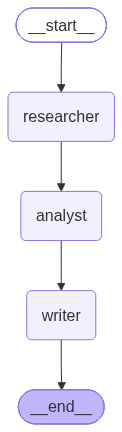

In [51]:
from IPython.display import Image, display

display(
    Image(
        final_workflow.get_graph().draw_mermaid_png()
    )
)

In [60]:
result = final_workflow.invoke({"messages":"what is the recent ai news what are the changes are made in ai , what should we need to learn to 1 cr salary.."})
result

{'messages': [HumanMessage(content='what is the recent ai news what are the changes are made in ai , what should we need to learn to 1 cr salary..', additional_kwargs={}, response_metadata={}, id='570765d4-2182-4efc-9e03-494563fb070a'),
  AIMessage(content='## 1.  The “what’s‑new” snapshot (August\u202f2026)\n\n| Category | Recent headline | Why it matters |\n|----------|-----------------|----------------|\n| **Foundation models** | **OpenAI releases GPT‑4.5‑Turbo** (Feb\u202f2026) – a 3‑x faster, 1‑x cheaper inference engine with 100\u202fB parameters, multi‑modal (text\u202f+\u202fimage\u202f+\u202faudio). | Enables cheaper, higher‑throughput LLM‑powered products. |\n| | **Google Gemini\u202f1.5** (Apr\u202f2026) – a multimodal model that can read PDFs, spreadsheets, and code, and can “self‑debug” code snippets. | Drives productivity tools (Docs, Sheets) and cloud APIs. |\n| | **Claude\u202f3.5** (Jun\u202f2026) – a 200\u202fB‑parameter model that supports “reasoning‑by‑retrieval” an

In [61]:
result["messages"][-1].pretty_print()

================================== Ai Message ==================================

## 1.  Recent AI Highlights (Jan – Aug 2026)

| Domain | Latest milestone | Why it matters |
|--------|------------------|----------------|
| **Large‑Language Models** | **OpenAI GPT‑4.5‑Turbo** – 3× faster, 1× cheaper, 100 B params, multimodal (text + image + audio). | Enables high‑throughput, low‑cost LLM services. |
| | **Google Gemini 1.5** – reads PDFs, spreadsheets, code and can “self‑debug”. | Integrated into Docs/Sheets; API for enterprise workflow automation. |
| | **Claude 3.5** – reasoning‑by‑retrieval + memory‑chain. | Popular in legal‑tech & compliance. |
| | **Meta Llama‑3.1** – 70 B params, open‑source, low‑latency edge inference. | Deployable on phones, IoT, edge servers. |
| **Generative AI** | **Stable Diffusion 3.0 / Midjourney V4** – 8K resolution, 3‑D mesh, real‑time style‑transfer on mobile. | Content creation, design, AR/VR. |
| | **Audio** – OpenAI Jukebox‑V2 & ElevenLabs Voice‑2‑V

In [62]:
for message in result["messages"]:
    message.pretty_print()

================================ Human Message =================================

what is the recent ai news what are the changes are made in ai , what should we need to learn to 1 cr salary..
================================== Ai Message ==================================

## 1.  The “what’s‑new” snapshot (August 2026)

| Category | Recent headline | Why it matters |
|----------|-----------------|----------------|
| **Foundation models** | **OpenAI releases GPT‑4.5‑Turbo** (Feb 2026) – a 3‑x faster, 1‑x cheaper inference engine with 100 B parameters, multi‑modal (text + image + audio). | Enables cheaper, higher‑throughput LLM‑powered products. |
| | **Google Gemini 1.5** (Apr 2026) – a multimodal model that can read PDFs, spreadsheets, and code, and can “self‑debug” code snippets. | Drives productivity tools (Docs, Sheets) and cloud APIs. |
| | **Claude 3.5** (Jun 2026) – a 200 B‑parameter model that supports “reasoning‑by‑retrieval” and a new “memory‑chain” feature. | Popular in lega

In [66]:
#Supervisor Multi Ai agent architecture.

from typing import TypedDict, Annotated, List, Literal, Dict, Any
from langchain_core.messages import BaseMessage, HumanMessage, AIMessage, SystemMessage
from langgraph.graph import StateGraph, END, MessagesState
from langgraph.checkpoint.memory import MemorySaver
import random
from datetime import datetime

In [ ]:
"""
class SupervisorState(MessagesState):
    """State for the Supervisor multi-agent system"""

    current_agent : str = ""
    task_assignments: Dict[str, List[str]] = {} #Track what each agent should do.
    agent_outputs:Dict[str, Any] = {} #Store the outputs from each agent.
    workflow_stage: str = "initial" #Track workflow progress.
    iteration_count: int = 0
    max_iteration: int = 10
    final_output: str = ""

"""


In [70]:
from typing import Literal

class SupervisorState(MessagesState):
    """State for the multi-agent system"""

    next_agent: Literal[
        "researcher",
        "analyst",
        "writer",
        "FINISH"
    ]

    research_agent: str
    analysis: str
    final_report: str
    task_complete: bool
    current_task: str

In [71]:
from langchain_core.prompts import ChatPromptTemplate


def create_supervisor_chain():
    """Creates the supervisor decision chain."""

    supervisor_prompt = ChatPromptTemplate.from_messages([
        (
            "system",
            """You are a supervisor managing a team of agents.

Your team consists of:

1. Researcher - Gather information and data.
2. Analyst - Analyze the data and provide insights.
3. Writer - Create reports and summaries.

Based on the current state and conversation, decide which
agent should work next.

Follow this general workflow:

Researcher → Analyst → Writer → DONE

Current State:
- Has research data: {has_research}
- Has analysis: {has_analysis}
- Has report: {has_report}

Respond with ONLY one of these values:
researcher
analyst
writer
DONE
"""
        ),
        (
            "human",
            "{task}"
        )
    ])

    return supervisor_prompt | llm

In [82]:
def supervisor_agent(state: SupervisorState) -> Dict:
    """Supervisor decides next agent using GROQ LLM."""

    messages = state["messages"]
    task = messages[0].content if messages else "No task"

    has_research = bool(state.get("research_data", "").strip())
    has_analysis = bool(state.get("analysis", "").strip())
    has_report = bool(state.get("final_report", "").strip())

    # First protect the workflow using state
    if has_report:
        next_agent = "end"

    elif not has_research:
        next_agent = "researcher"

    elif not has_analysis:
        next_agent = "analyst"

    else:
        next_agent = "writer"

    # Create supervisor message
    if next_agent == "researcher":
        supervisor_msg = (
            "Supervisor: Let's start with research. "
            "Assigning to researcher..."
        )

    elif next_agent == "analyst":
        supervisor_msg = (
            "Supervisor: Research is complete. "
            "Assigning to analyst..."
        )

    elif next_agent == "writer":
        supervisor_msg = (
            "Supervisor: Analysis is complete. "
            "Assigning to writer..."
        )

    else:
        supervisor_msg = (
            "Supervisor: All tasks completed! Great work team."
        )

    print(f"Supervisor decision: {next_agent}")

    return {
        "messages": [AIMessage(content=supervisor_msg)],
        "next_agent": next_agent,
        "current_task": task
    }

In [83]:
def researcher_agent(state: SupervisorState) -> Dict:
    """Researcher uses Groq to gather research findings."""

    task = state.get("current_task", "")

    # Create research prompt.
    research_prompt = f"""
    You are a professional research analyst.

    Research the following task and provide accurate and useful findings:

    Task: {task}

    Focus on:
    1. Important facts and background information
    2. Recent developments and trends
    3. Key statistics or evidence
    4. Important organizations, people, or technologies involved
    5. Relevant insights that can help with further analysis

    Keep the research factual, relevant, and concise.
    """

    # Get research from LLM.
    research_response = llm.invoke(
        [HumanMessage(content=research_prompt)]
    )

    research_data = research_response.content

    # Create formatted research output.
    formatted_research = f"""
RESEARCH FINDINGS
{'=' * 50}
Topic: {task}
{'=' * 50}

{research_data}

{'=' * 50}
Research completed by multi-agent AI system using Groq.
"""

    return {
        "messages": [
            AIMessage(
                content="Researcher: Research completed! Findings are ready for analysis."
            )
        ],
        "research_data": formatted_research,
        "next_agent": "supervisor"
    }

In [84]:
def analyst_agent(state: SupervisorState) -> Dict:
    """Analyst uses Groq to analyze the research findings."""

    research_data = state.get("research_data", "")
    task = state.get("current_task", "")

    # Create analysis prompt.
    analysis_prompt = f"""
    You are a professional data and business analyst.

    Analyze the following research findings and provide meaningful insights.

    Task: {task}

    Research Findings:
    {research_data[:2000]}

    Perform the following:

    1. Identify the key findings.
    2. Identify important trends and patterns.
    3. Explain the significance of the findings.
    4. Identify opportunities and potential risks.
    5. Provide actionable insights and recommendations.

    Keep the analysis logical, evidence-based, and concise.
    """

    # Get analysis from LLM.
    analysis_response = llm.invoke(
        [HumanMessage(content=analysis_prompt)]
    )

    analysis = analysis_response.content

    # Create formatted analysis output.
    formatted_analysis = f"""
ANALYSIS & INSIGHTS
{'=' * 50}
Topic: {task}
{'=' * 50}

{analysis}

{'=' * 50}
Analysis completed by multi-agent AI system using Groq.
"""

    return {
        "messages": [
            AIMessage(
                content="Analyst: Analysis completed! Insights are ready for the writer."
            )
        ],
        "analysis": formatted_analysis,
        "next_agent": "supervisor"
    }

In [75]:
def writer_agent(state: SupervisorState) -> Dict:
    """Writer uses Groq to create the final report."""

    research_data = state.get("research_data", "")
    analysis = state.get("analysis", "")
    task = state.get("current_task", "")

    # Create writing prompt.
    writing_prompt = f"""
    As a professional writer, create an executive report based on:

    Task: {task}

    Research Findings:
    {research_data[:1000]}

    Analysis:
    {analysis[:1000]}

    Create a well-structured report with:

    1. Executive Summary
    2. Key Findings
    3. Analysis & Insights
    4. Recommendations
    5. Conclusion

    Keep it professional and concise.
    """

    # Get report from LLM.
    report_response = llm.invoke(
        [HumanMessage(content=writing_prompt)]
    )

    report = report_response.content

    # Create final formatted report.
    final_report = f"""
FINAL REPORT
{'=' * 50}
Generated: {datetime.now().strftime('%Y-%m-%d %H:%M')}
Topic: {task}
{'=' * 50}

{report}

{'=' * 50}
Report compiled by multi-agent AI system using Groq.
"""

    return {
        "messages": [
            AIMessage(
                content="Writer: Report complete! See below for the full document."
            )
        ],
        "final_report": final_report,
        "next_agent": "supervisor",
        "task_complete": True
    }

In [85]:
def router_function(state: SupervisorState) -> str:
    """Route to the next agent based on supervisor's decision."""

    next_agent = state.get("next_agent", "end")

    if next_agent == "researcher":
        return "researcher"

    elif next_agent == "analyst":
        return "analyst"

    elif next_agent == "writer":
        return "writer"

    elif next_agent == "supervisor":
        return "supervisor"

    elif next_agent == "end":
        return "end"

    else:
        return "end"

In [89]:
from langgraph.graph import StateGraph, START, END

# Create workflow
workflow = StateGraph(SupervisorState)

# Add nodes
workflow.add_node("supervisor", supervisor_agent)
workflow.add_node("researcher", researcher_agent)
workflow.add_node("analyst", analyst_agent)
workflow.add_node("writer", writer_agent)

# START → Supervisor
workflow.add_edge(START, "supervisor")

# Supervisor → next agent
workflow.add_conditional_edges(
    "supervisor",
    router_function,
    {
        "researcher": "researcher",
        "analyst": "analyst",
        "writer": "writer",
        "end": END
    }
)

# Worker → Supervisor
workflow.add_edge("researcher", "supervisor")
workflow.add_edge("analyst", "supervisor")
workflow.add_edge("writer", "supervisor")

# Compile
graph = workflow.compile()

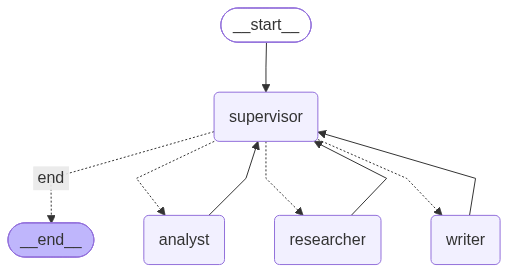

In [90]:
graph

In [ ]:
response = graph.invoke(HumanMessage(content = "What are the benefits and risks of AI in healthcare ?"))
response